# F1 Pit Stop Prediction — Exploratory Data Analysis

**Dataset**: Kaggle Playground Series S6E5 — F1 Strategy Dataset  
**Target**: `PitNextLap` — whether a car will pit in the next lap (binary: 0 / 1)  
**Storage**: Raw data loaded from AWS S3



## 0. Imports

In [43]:
import boto3
import io
import os
import warnings
warnings.filterwarnings('ignore')
from dotenv import load_dotenv
load_dotenv(override=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})


C_POS  = '#e53935'
C_NEG  = '#1e88e5'

## 1. Load Data from S3

Data is stored in our S3 bucket under `raw/`.  
AWS credentials are provided via the EC2 IAM Role — **no keys are hardcoded**.

In [44]:
"""
# if you prefer upload via boto3 instead of AWS website, here is the code.

import boto3
import os

s3 = boto3.client(
    's3',
    aws_access_key_id     = os.environ['AWS_ACCESS_KEY_ID'],
    aws_secret_access_key = os.environ['AWS_SECRET_ACCESS_KEY'],
    region_name           = 'ap-southeast-1'
)

BUCKET = 'f1-pitstop-bucket'

def upload_file(local_path: str, s3_key: str):
    s3.upload_file(local_path, BUCKET, s3_key)

upload_file('data/train.csv', 'raw/train.csv')
upload_file('data/test.csv',  'raw/test.csv')
"""

"\n# if you prefer upload via boto3 instead of AWS website, here is the code.\n\nimport boto3\nimport os\n\ns3 = boto3.client(\n    's3',\n    aws_access_key_id     = os.environ['AWS_ACCESS_KEY_ID'],\n    aws_secret_access_key = os.environ['AWS_SECRET_ACCESS_KEY'],\n    region_name           = 'ap-southeast-1'\n)\n\nBUCKET = 'f1-pitstop-bucket'\n\ndef upload_file(local_path: str, s3_key: str):\n    s3.upload_file(local_path, BUCKET, s3_key)\n\nupload_file('data/train.csv', 'raw/train.csv')\nupload_file('data/test.csv',  'raw/test.csv')\n"

In [45]:
from sklearn.model_selection import train_test_split
BUCKET = os.environ.get('S3_BUCKET', 'f1-pitstop-bucket')
PREFIX = 'raw/'

s3 = boto3.client('s3')

def read_csv_from_s3(bucket: str, key: str) -> pd.DataFrame:
    obj = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(obj['Body'].read()))
df = read_csv_from_s3(BUCKET, PREFIX + 'train.csv').set_index('id')
TARGET = 'PitNextLap'

train, test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df[TARGET]
)

print(f'Train : {train.shape[0]:,} rows × {train.shape[1]} cols')
print(f'Test  : {test.shape[0]:,} rows × {test.shape[1]} cols')

print('\nOriginal target ratio:')
print(df[TARGET].value_counts(normalize=True))

print('\nTrain target ratio:')
print(train[TARGET].value_counts(normalize=True))

print('\nTest target ratio:')
print(test[TARGET].value_counts(normalize=True))

Train : 351,312 rows × 15 cols
Test  : 87,828 rows × 15 cols

Original target ratio:
PitNextLap
0.0    0.801018
1.0    0.198982
Name: proportion, dtype: float64

Train target ratio:
PitNextLap
0.0    0.801017
1.0    0.198983
Name: proportion, dtype: float64

Test target ratio:
PitNextLap
0.0    0.80102
1.0    0.19898
Name: proportion, dtype: float64


## 2. Basic Info & Missing Values

In [46]:
print('Data Types')
print(train.dtypes)

num_cols = train.drop(columns=TARGET).select_dtypes(include='number').columns.tolist()
cat_cols = train.drop(columns=TARGET).select_dtypes(exclude='number').columns.tolist()

print(f'\nNumerical features  ({len(num_cols)}): {num_cols}')
print(f'Categorical features ({len(cat_cols)}): {cat_cols}')

Data Types
Driver                        str
Compound                      str
Race                          str
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
PitNextLap                float64
dtype: object

Numerical features  (11): ['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']
Categorical features (3): ['Driver', 'Compound', 'Race']


In [47]:
# Descriptive statistics
train[num_cols].describe().T.style.format('{:.2f}')

,count,mean,std,min,25%,50%,75%,max
Year,351312.00,2023.52,1.03,2022.00,2023.00,2024.00,2024.00,2025.00
PitStop,351312.00,0.14,0.34,0.00,0.00,0.00,0.00,1.00
LapNumber,351312.00,23.11,16.96,1.00,9.00,19.00,36.00,78.00
Stint,351312.00,1.79,0.95,1.00,1.00,2.00,2.00,8.00
TyreLife,351312.00,14.16,9.81,1.00,6.00,12.00,20.00,77.00
Position,351312.00,9.63,5.28,1.00,5.00,10.00,14.00,20.00
LapTime (s),351312.00,90.95,20.17,67.69,82.62,90.51,98.46,2502.81
LapTime_Delta,351312.00,-3.77,44.28,-2403.89,-8.88,-0.30,0.11,2423.93
Cumulative_Degradation,351312.00,-25.66,54.88,-274.56,-46.55,-20.99,-6.18,2412.03
RaceProgress,351312.00,0.34,0.25,0.01,0.13,0.27,0.51,1.00


In [48]:
# Missing values
missing = pd.DataFrame({
    'Missing (train)': train.isna().sum(),
    'Missing (test)' : test.isna().sum(),
})
missing = missing[missing.sum(axis=1) > 0]

if missing.empty:
    print('No missing values in either split.')
else:
    display(missing)

No missing values in either split.


## 3. Target Distribution

`PitNextLap = 1` means the car pits on the following lap.  
This is a **binary classification** task. We check for class imbalance here.

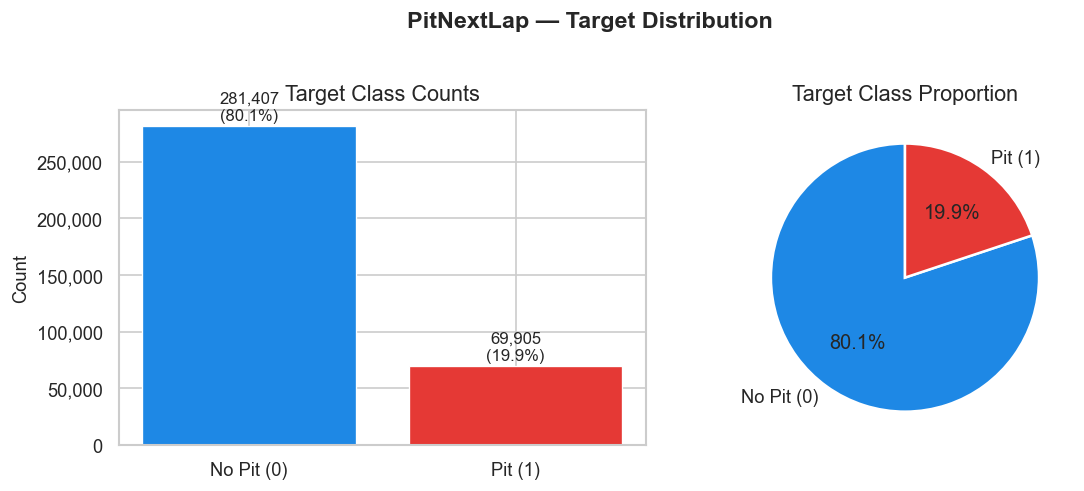

Class imbalance ratio (0:1) = 4.0:1


In [49]:
counts = train[TARGET].value_counts()
pct    = train[TARGET].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(['No Pit (0)', 'Pit (1)'], counts.values,
            color=[C_NEG, C_POS], edgecolor='white', linewidth=0.8)
for i, (v, p) in enumerate(zip(counts.values, pct.values)):
    axes[0].text(i, v + counts.max() * 0.01, f'{v:,}\n({p:.1f}%)',
                 ha='center', va='bottom', fontsize=10)
axes[0].set_title('Target Class Counts')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
axes[1].pie(counts.values,
            labels=['No Pit (0)', 'Pit (1)'],
            autopct='%1.1f%%',
            colors=[C_NEG, C_POS],
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Target Class Proportion')

plt.suptitle('PitNextLap — Target Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

ratio = counts[0] / counts[1]
print(f'Class imbalance ratio (0:1) = {ratio:.1f}:1')

## 4. Numerical Features

We compare each numerical feature's distribution across the **train** and **test** splits  
to check for data drift.

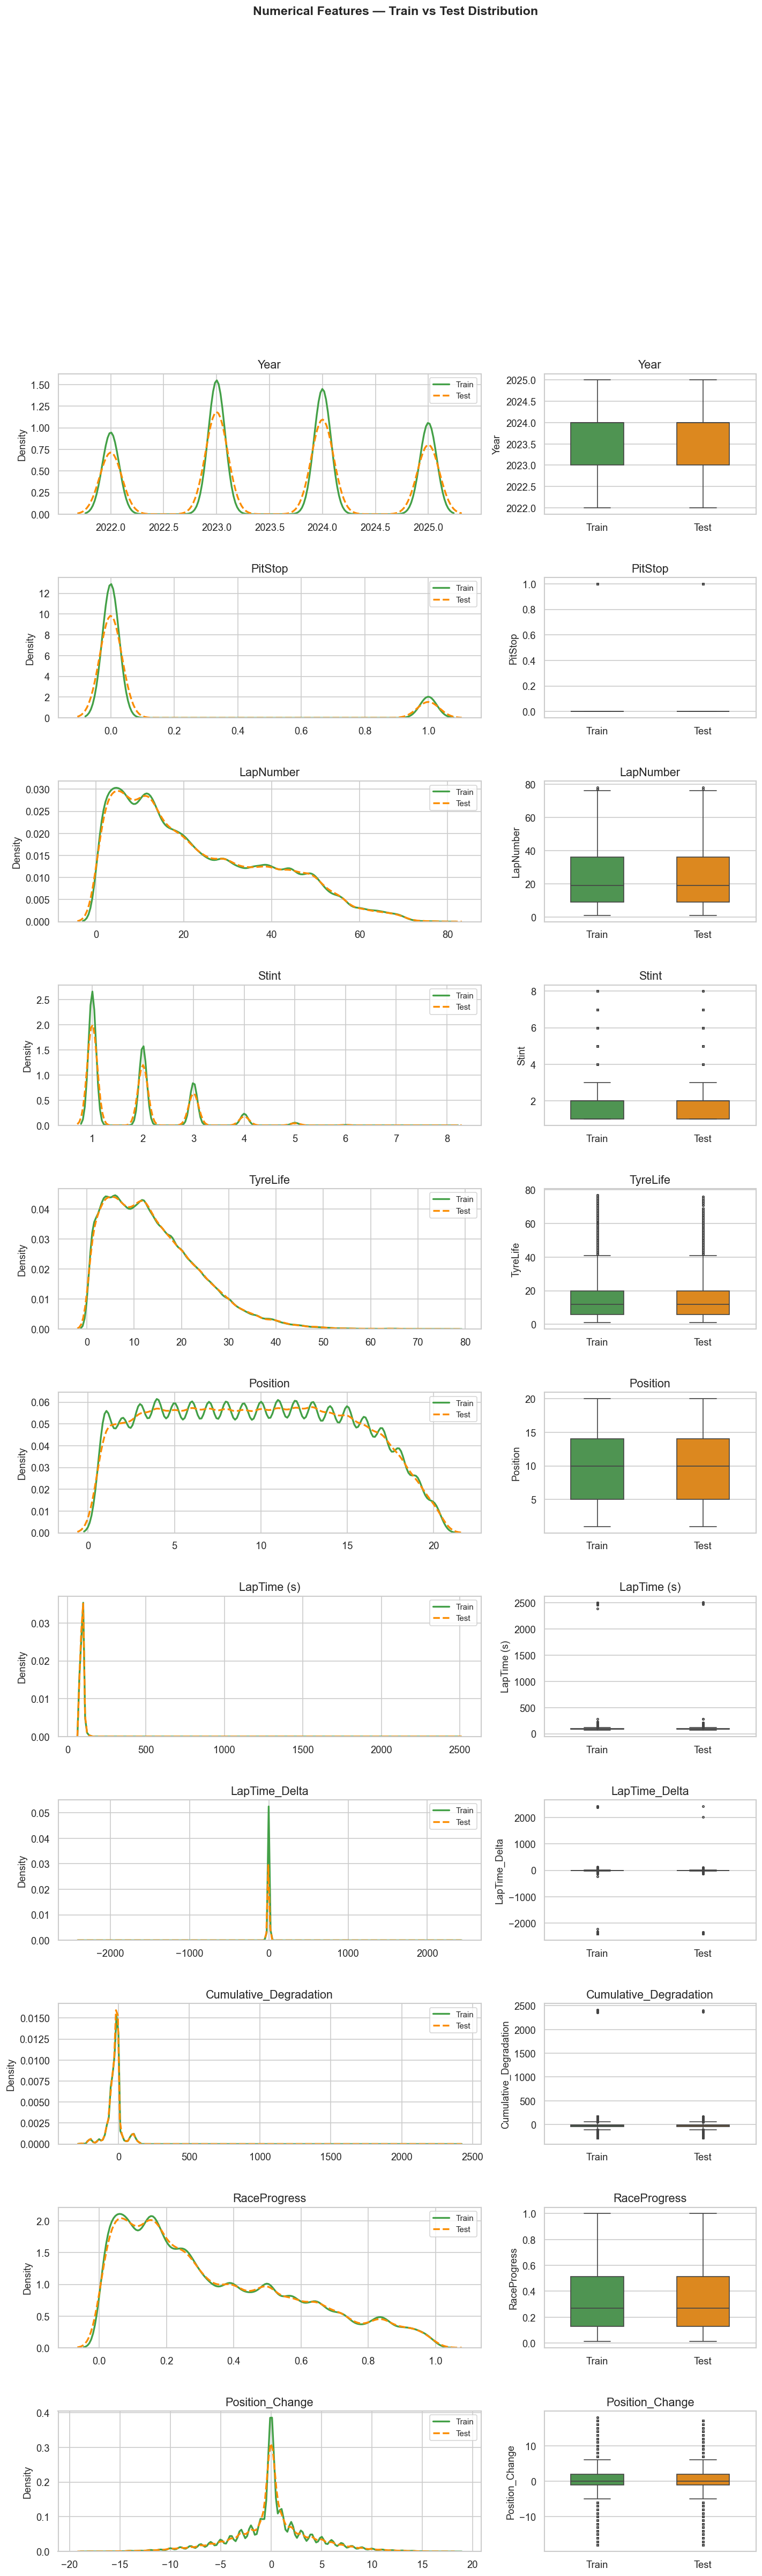

In [50]:
n = len(num_cols)
fig, axes = plt.subplots(n, 2, figsize=(14, n * 4),
                          gridspec_kw={'width_ratios': [2, 1], 'hspace': 0.45})

for i, col in enumerate(num_cols):
    ax_kde, ax_box = axes[i]

    # KDE — train vs test
    sns.kdeplot(train[col], ax=ax_kde, color= "#43a047", linewidth=2, label='Train')
    sns.kdeplot(test[col],  ax=ax_kde, color='#fb8c00', linewidth=2,
                linestyle='--', label='Test')
    ax_kde.set_title(col)
    ax_kde.set_xlabel('')
    ax_kde.legend(fontsize=9)

    # Box — train vs test
    plot_df = pd.concat([
        train[[col]].assign(Split='Train'),
        test[[col]].assign(Split='Test'),
    ])
    sns.boxplot(data=plot_df, x='Split', y=col, ax=ax_box,
                palette={'Train': "#43a047", 'Test': '#fb8c00'},
                width=0.5, linewidth=1, fliersize=2)
    ax_box.set_title(col)
    ax_box.set_xlabel('')

plt.suptitle('Numerical Features — Train vs Test Distribution', fontsize=14,
             fontweight='bold', y=1.01)
plt.show()

In [51]:
def psi(expected, actual, bins=10, eps=1e-4):
    e = expected.dropna().to_numpy()
    a = actual.dropna().to_numpy()
    bp = np.unique(np.quantile(e, np.linspace(0, 1, bins+1)))
    bp[0], bp[-1] = -np.inf, np.inf
    ec = np.histogram(e, bp)[0] + eps
    ac = np.histogram(a, bp)[0] + eps
    ec, ac = ec/ec.sum(), ac/ac.sum()
    return np.sum((ec - ac) * np.log(ec / ac))

psi_scores = {col: psi(train[col], test[col]) for col in num_cols}
pd.Series(psi_scores).sort_values(ascending=False).rename("PSI")

Cumulative_Degradation    0.000146
Position                  0.000140
LapTime_Delta             0.000115
LapNumber                 0.000085
Position_Change           0.000056
TyreLife                  0.000051
RaceProgress              0.000046
LapTime (s)               0.000042
Year                      0.000022
Stint                     0.000004
PitStop                   0.000000
Name: PSI, dtype: float64

In [52]:
# Skewness summary
skew_df = pd.DataFrame({
    'Skewness': train[num_cols].skew(),
    'Kurtosis': train[num_cols].kurt(),
}).round(3)

skew_df.style.background_gradient(cmap='RdYlGn_r', subset=['Skewness']) \
             .background_gradient(cmap='Blues', subset=['Kurtosis'])

,Skewness,Kurtosis
Year,-0.001000,-1.132000
PitStop,2.119000,2.490000
LapNumber,0.646000,-0.566000
Stint,1.183000,1.273000
TyreLife,1.036000,1.457000
Position,0.070000,-1.101000
LapTime (s),80.251000,9474.569000
LapTime_Delta,-40.147000,2643.500000
Cumulative_Degradation,3.318000,161.266000
RaceProgress,0.700000,-0.515000


## 5. Categorical Features

We plot the top-10 most frequent values for each categorical feature,  
comparing train and test to spot distribution differences.

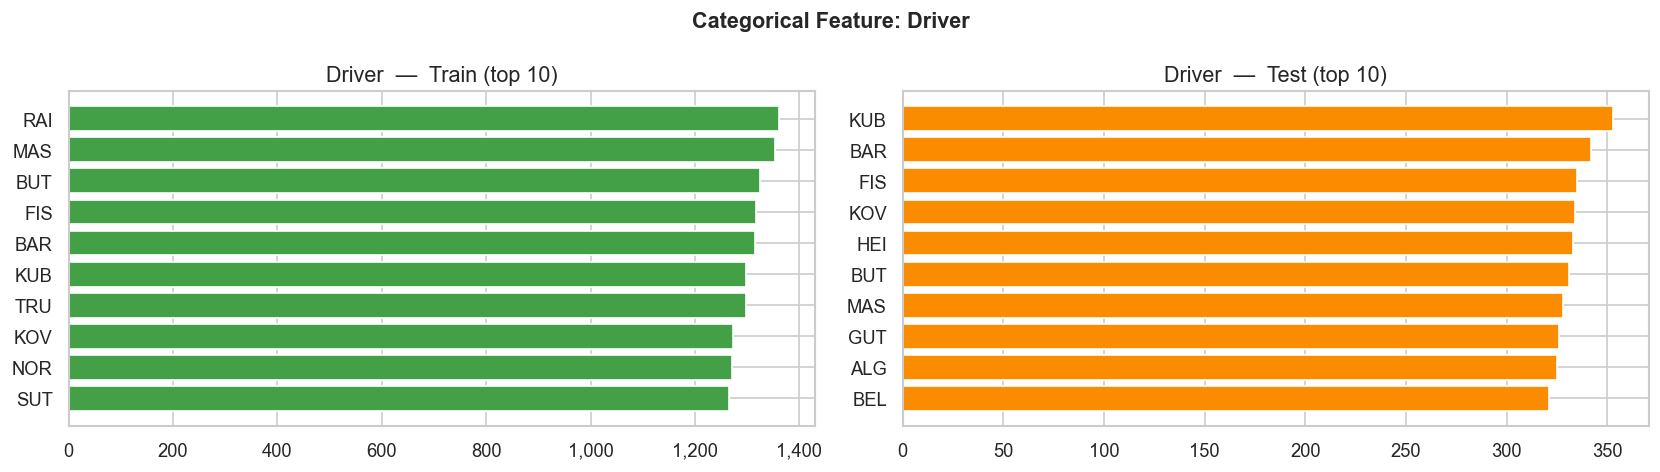

  Train unique: 864   |   Test unique: 766



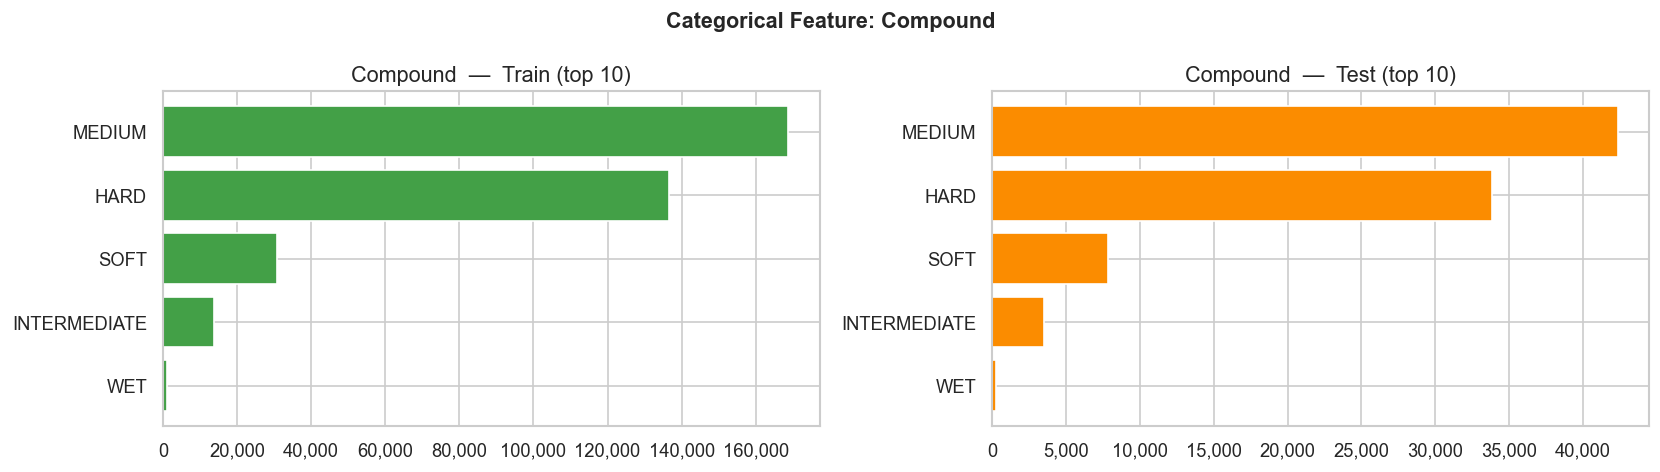

  Train unique: 5   |   Test unique: 5



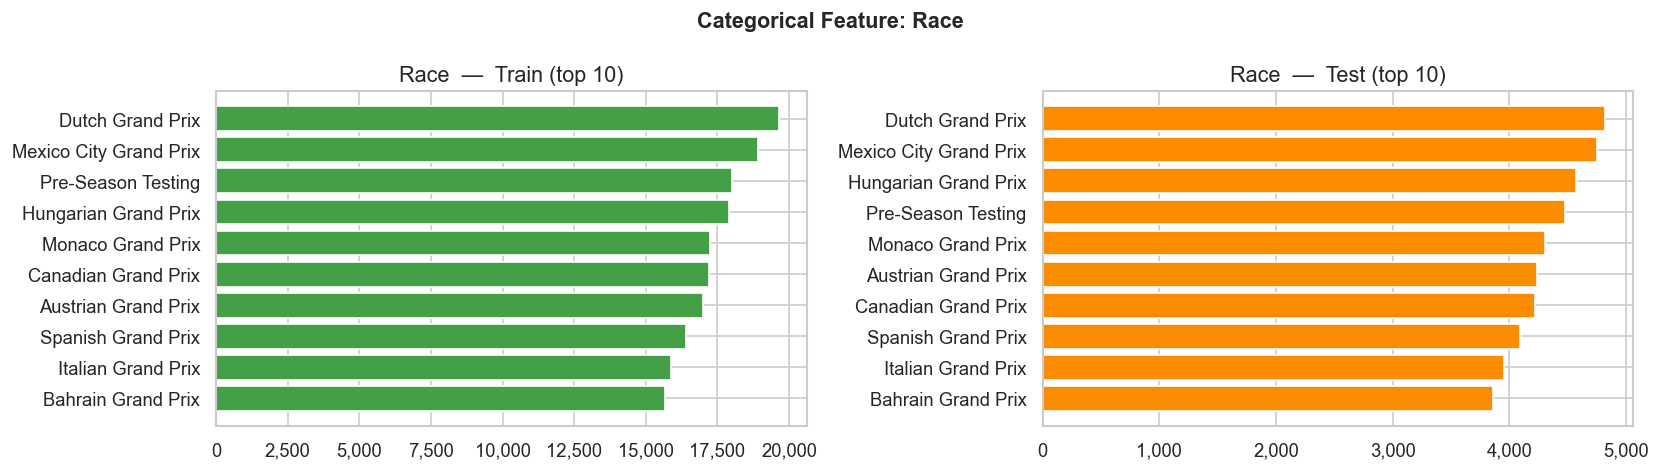

  Train unique: 26   |   Test unique: 26



In [53]:
for col in cat_cols:
    top_train = train[col].value_counts().nlargest(10)
    top_test  = test[col].value_counts().nlargest(10)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].barh(top_train.index[::-1], top_train.values[::-1], color="#43a047")
    axes[0].set_title(f'{col}  —  Train (top 10)')
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    axes[1].barh(top_test.index[::-1], top_test.values[::-1], color='#fb8c00')
    axes[1].set_title(f'{col}  —  Test (top 10)')
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.suptitle(f'Categorical Feature: {col}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Unique value count
    print(f'  Train unique: {train[col].nunique()}   |   '
          f'Test unique: {test[col].nunique()}\n')

## 6. Correlation Analysis

Spearman correlation is used because it captures **monotonic** relationships  
and is robust to outliers and non-normal distributions.

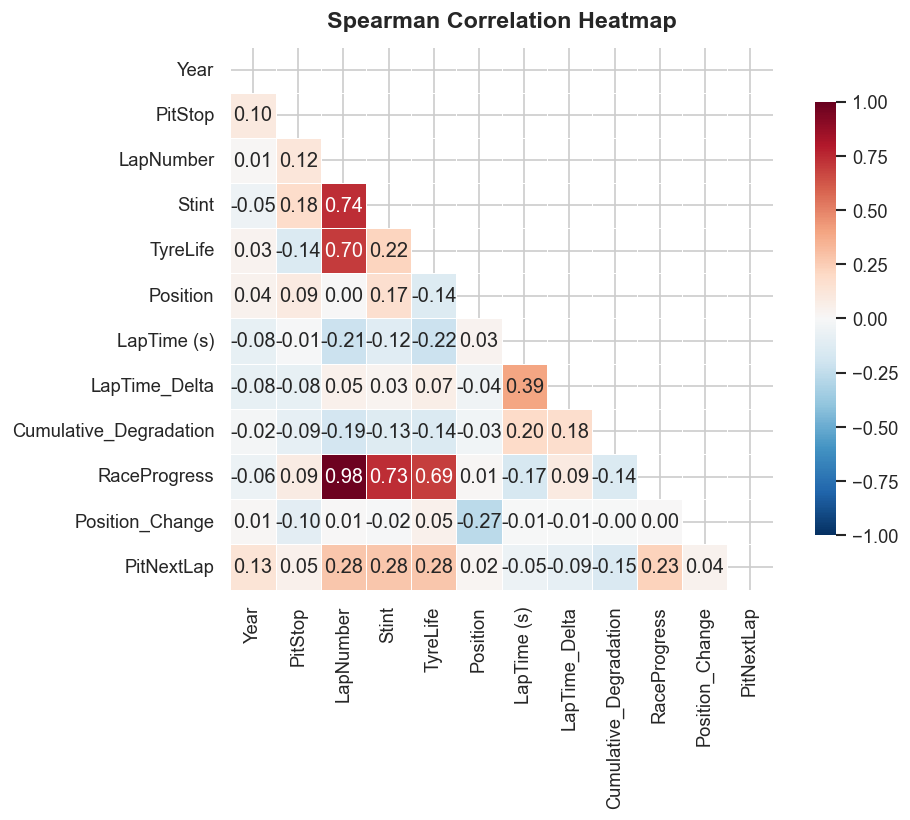

In [54]:
corr_cols = num_cols + [TARGET]
corr = train[corr_cols].corr(method='spearman')

mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            ax=ax)
ax.set_title('Spearman Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

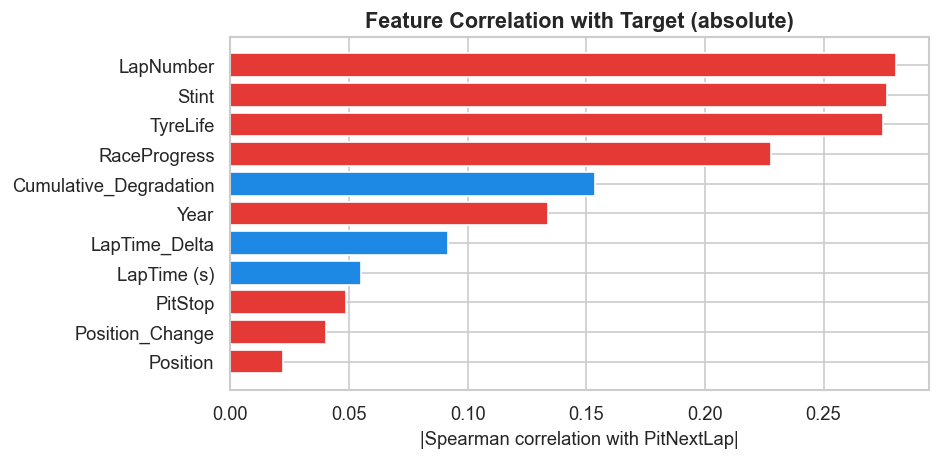

In [55]:
# Correlation with target (ranked)
target_corr = (corr[TARGET]
               .drop(TARGET)
               .abs()
               .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = [C_POS if v > 0 else C_NEG
          for v in corr[TARGET].drop(TARGET).loc[target_corr.index]]
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1])
ax.set_xlabel('|Spearman correlation with PitNextLap|')
ax.set_title('Feature Correlation with Target (absolute)', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature vs Target

We examine how each feature's distribution **shifts** between pit (1) and no-pit (0) laps.

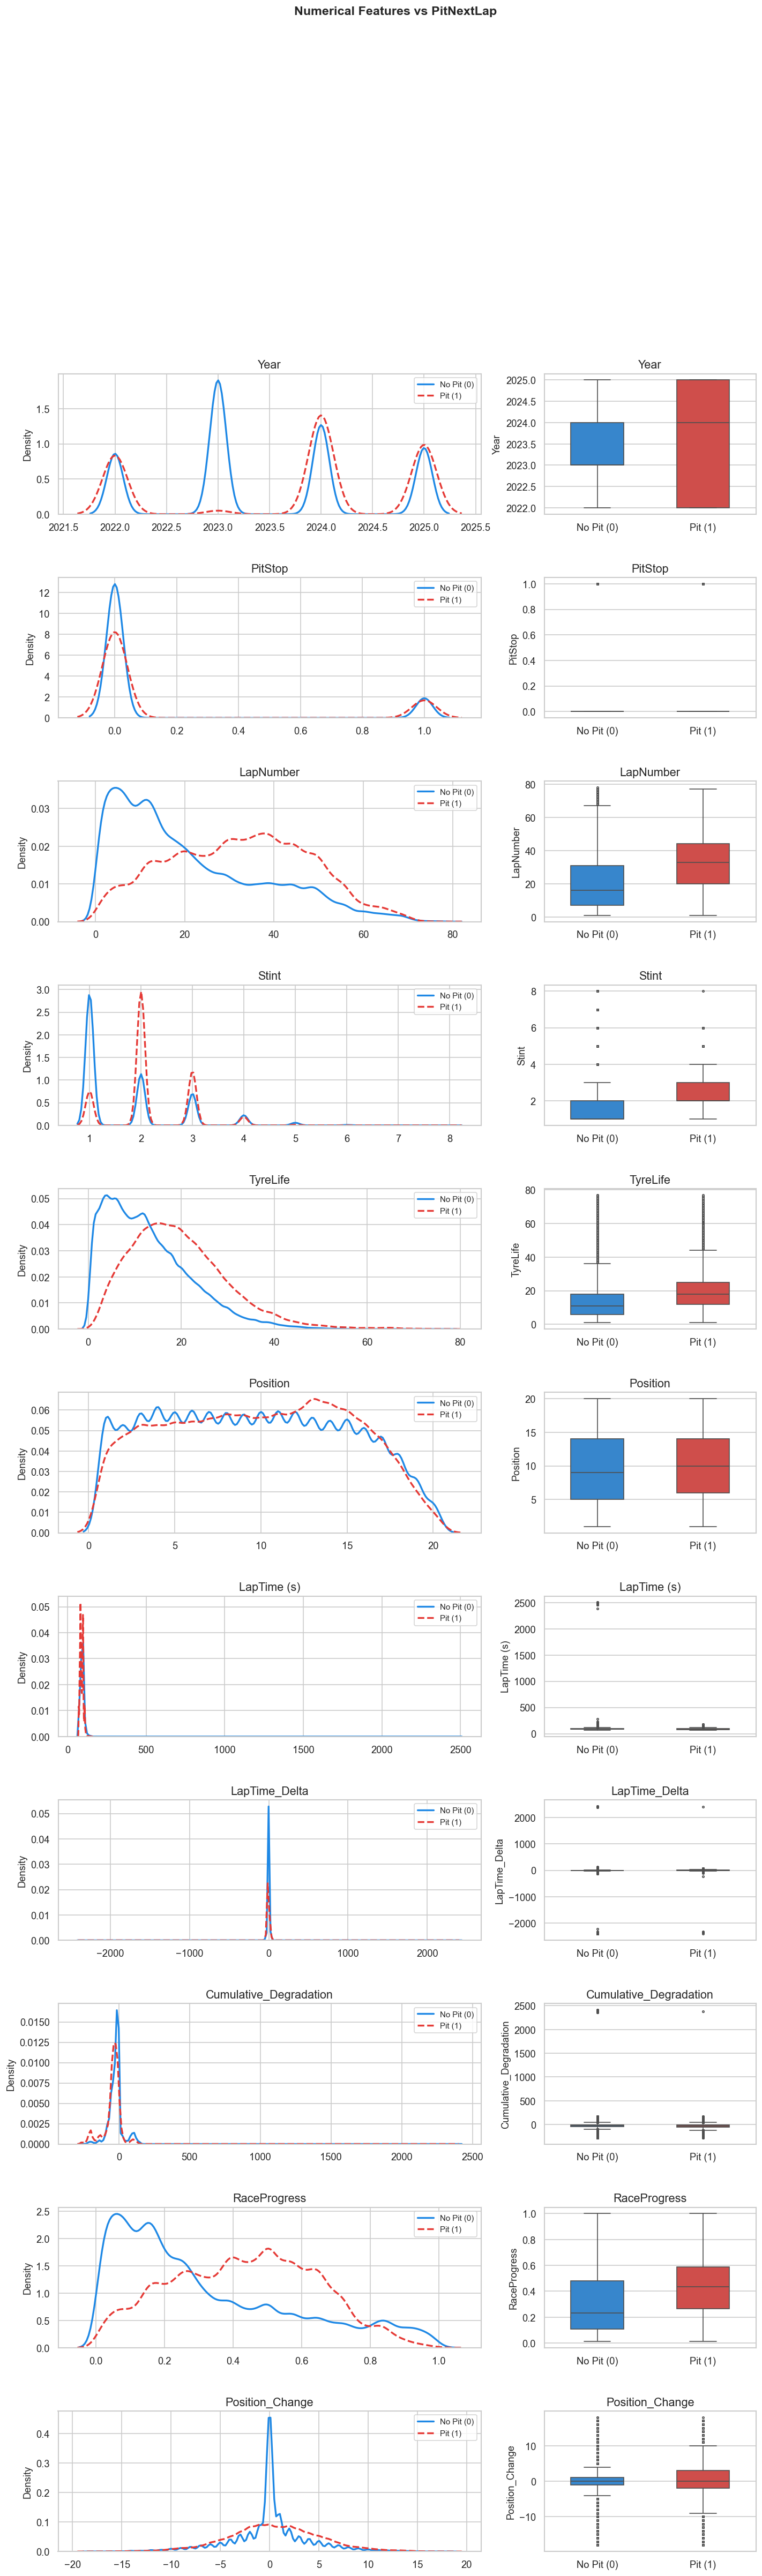

In [56]:
# Numerical features vs target
pit     = train[train[TARGET] == 1]
no_pit  = train[train[TARGET] == 0]

n = len(num_cols)
fig, axes = plt.subplots(n, 2, figsize=(14, n * 4),
                          gridspec_kw={'width_ratios': [2, 1], 'hspace': 0.45})

for i, col in enumerate(num_cols):
    ax_kde, ax_box = axes[i]

    # KDE — pit vs no pit
    sns.kdeplot(no_pit[col], ax=ax_kde, color=C_NEG, linewidth=2, label='No Pit (0)')
    sns.kdeplot(pit[col],    ax=ax_kde, color=C_POS, linewidth=2,
                linestyle='--', label='Pit (1)')
    ax_kde.set_title(col)
    ax_kde.set_xlabel('')
    ax_kde.legend(fontsize=9)

    # Box — pit vs no pit
    plot_df = pd.concat([
        no_pit[[col]].assign(Label='No Pit (0)'),
        pit[[col]].assign(Label='Pit (1)'),
    ])
    sns.boxplot(data=plot_df, x='Label', y=col, ax=ax_box,
                palette={'No Pit (0)': C_NEG, 'Pit (1)': C_POS},
                width=0.5, linewidth=1, fliersize=2)
    ax_box.set_title(col)
    ax_box.set_xlabel('')

plt.suptitle('Numerical Features vs PitNextLap', fontsize=14,
             fontweight='bold', y=1.01)
plt.show()

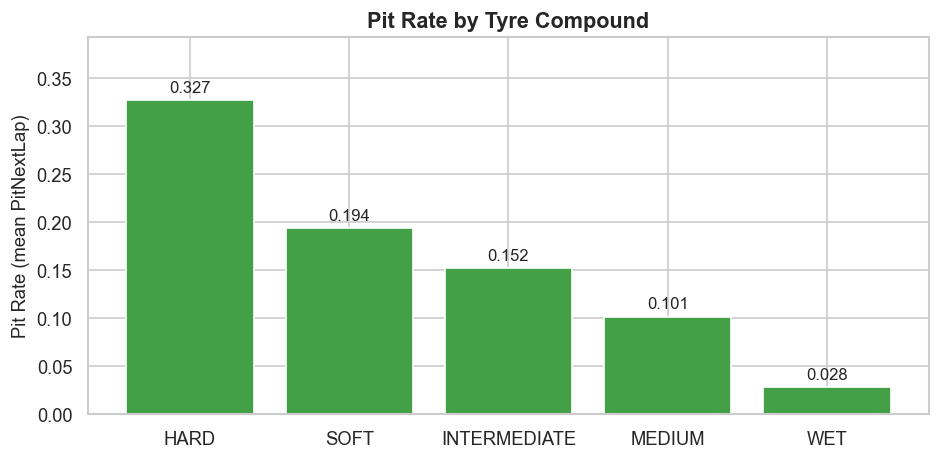

In [57]:
# Pit rate by Compound
compound_pit_rate = (train.groupby('Compound')[TARGET]
                         .mean()
                         .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(compound_pit_rate.index, compound_pit_rate.values,
              color="#43a047", edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
ax.set_ylim(0, compound_pit_rate.max() * 1.2)
ax.set_ylabel('Pit Rate (mean PitNextLap)')
ax.set_title('Pit Rate by Tyre Compound', fontweight='bold')
plt.tight_layout()
plt.show()

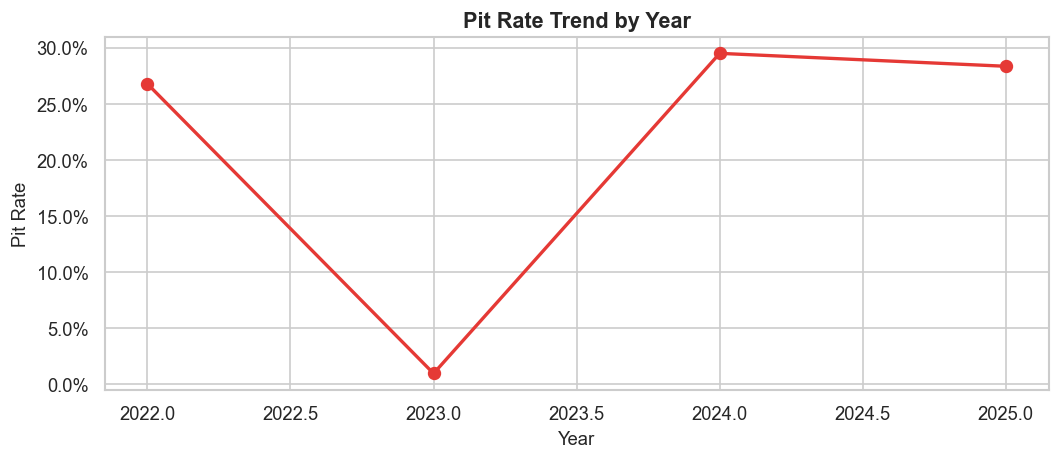

In [58]:
# Pit rate by Year
if 'Year' in train.columns:
    year_pit_rate = (train.groupby('Year')[TARGET]
                         .mean()
                         .sort_index())

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(year_pit_rate.index, year_pit_rate.values,
            marker='o', color=C_POS, linewidth=2, markersize=7)
    ax.set_xlabel('Year')
    ax.set_ylabel('Pit Rate')
    ax.set_title('Pit Rate Trend by Year', fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    plt.tight_layout()
    plt.show()

In [59]:
train.groupby('Year')[TARGET].value_counts()

Year  PitNextLap
2022  0.0            48683
      1.0            17794
2023  0.0           107722
      1.0             1055
2024  0.0            71754
      1.0            30004
2025  0.0            53248
      1.0            21052
Name: count, dtype: int64

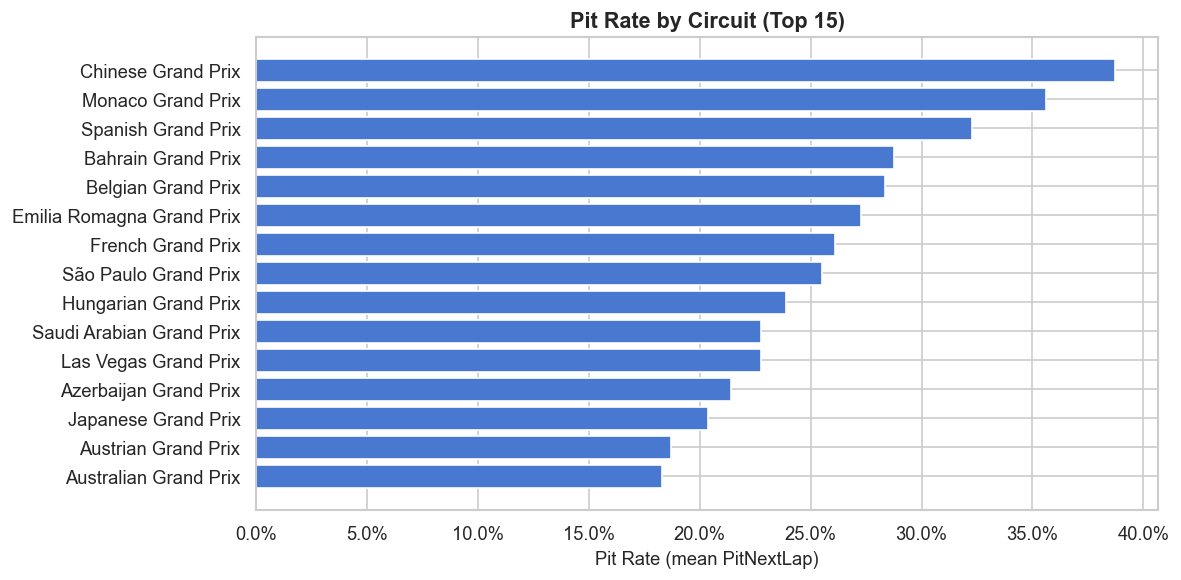

In [60]:
# Pit rate by Race
race_pit_rate = (train.groupby('Race')[TARGET]
                      .mean()
                      .sort_values(ascending=False)
                      .head(15))   # top 15 circuits

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(race_pit_rate.index[::-1], race_pit_rate.values[::-1])
ax.set_xlabel('Pit Rate (mean PitNextLap)')
ax.set_title('Pit Rate by Circuit (Top 15)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
plt.tight_layout()
plt.show()

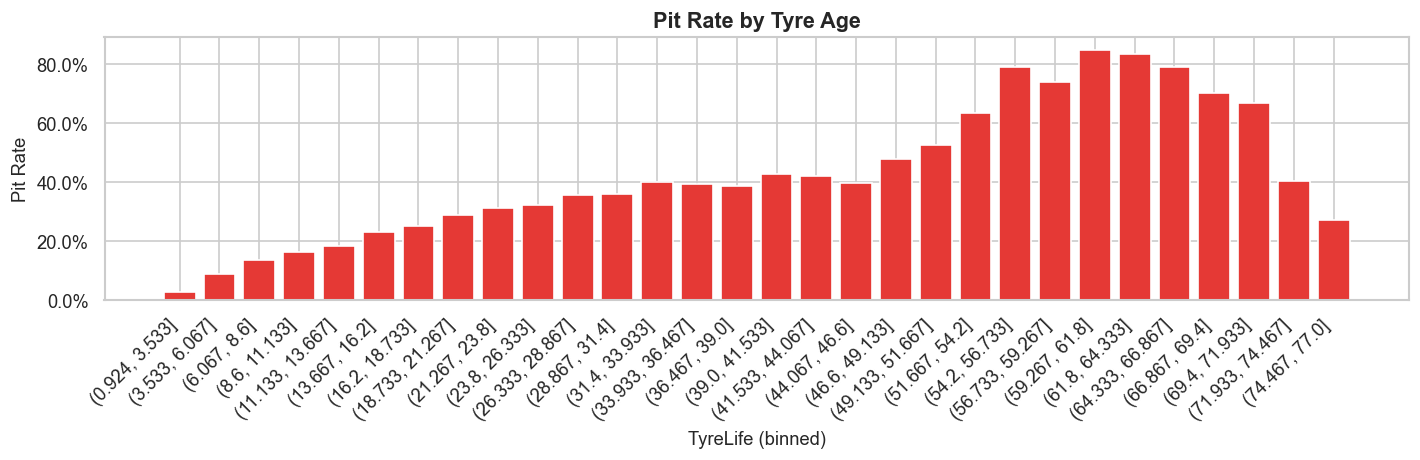

In [61]:
# TyreLife vs pit decision (binned view)
train['TyreLife_bin'] = pd.cut(train['TyreLife'], bins=30)
tyre_pit = train.groupby('TyreLife_bin', observed=True)[TARGET].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(tyre_pit.index.astype(str), tyre_pit.values, color=C_POS, edgecolor='white')
ax.set_xlabel('TyreLife (binned)')
ax.set_ylabel('Pit Rate')
ax.set_title('Pit Rate by Tyre Age', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

train.drop(columns='TyreLife_bin', inplace=True)

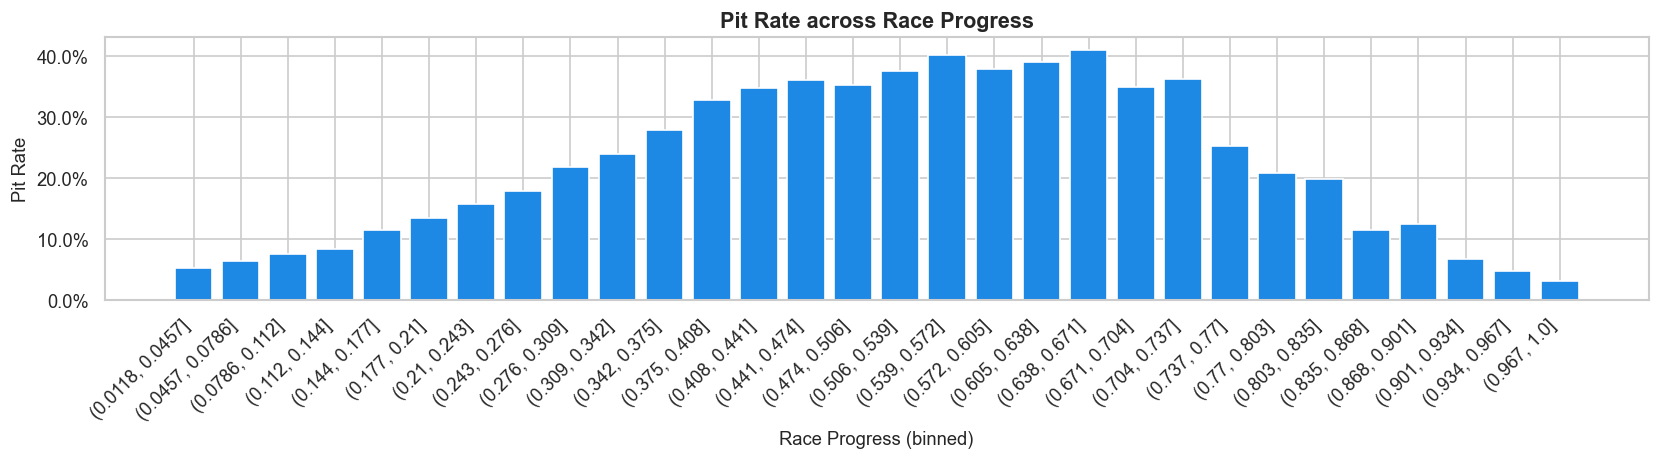

In [62]:
# RaceProgress vs pit decision (binned view)
train['RaceProgress_bin'] = pd.cut(train['RaceProgress'], bins=30)
progress_pit = train.groupby('RaceProgress_bin', observed=True)[TARGET].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(progress_pit.index.astype(str), progress_pit.values, color=C_NEG, edgecolor='white')
ax.set_xlabel('Race Progress (binned)')
ax.set_ylabel('Pit Rate')
ax.set_title('Pit Rate across Race Progress', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

train.drop(columns='RaceProgress_bin', inplace=True)

## 8. Key Insights

Summary of findings from the EDA:

In [63]:
# Print a concise insight summary
pit_rate_overall = train[TARGET].mean()
top_compound     = compound_pit_rate.idxmax()
top_corr_feat    = target_corr.idxmax()

print('=' * 55)
print('  EDA Key Insights — F1 Pit Stop Prediction')
print('=' * 55)
print(f'  Training rows          : {len(train):,}')
print(f'  Overall pit rate       : {pit_rate_overall:.1%}')
print(f'  Class imbalance (0:1)  : {(1 - pit_rate_overall)/pit_rate_overall:.1f}:1')
print(f'  Strongest corr. feature: {top_corr_feat} ({target_corr[top_corr_feat]:.3f})')
print(f'  Highest-pit compound   : {top_compound}')
print('=' * 55)
print()

  EDA Key Insights — F1 Pit Stop Prediction
  Training rows          : 351,312
  Overall pit rate       : 19.9%
  Class imbalance (0:1)  : 4.0:1
  Strongest corr. feature: LapNumber (0.280)
  Highest-pit compound   : HARD

